# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [ ]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

# Example:
# import pandas as pd

# TODO: Download any required NLTK resources.

# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...

# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows

# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer

# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens

# def preprocess_text(text):
#     pass

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

# TODO: Combine all tokens into one list so you can compute word frequencies.

# TODO: Use Counter to identify the most common words.

# TODO: Generate bigrams from the token list and identify the most common bigrams.

# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?


In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.util import bigrams

In [3]:
# TODO: Download any required NLTK resources

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# TODO: Load the dataset.
df = pd.read_csv('amazon_reviews_lab.csv')


,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [6]:
# TODO: Explore the dataset.
df.shape

(997, 9)

In [10]:
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB


In [ ]:
# Rating column value counts
df['rating'].value_counts()

rating
5    580
4    188
3     94
1     87
2     48
Name: count, dtype: int64

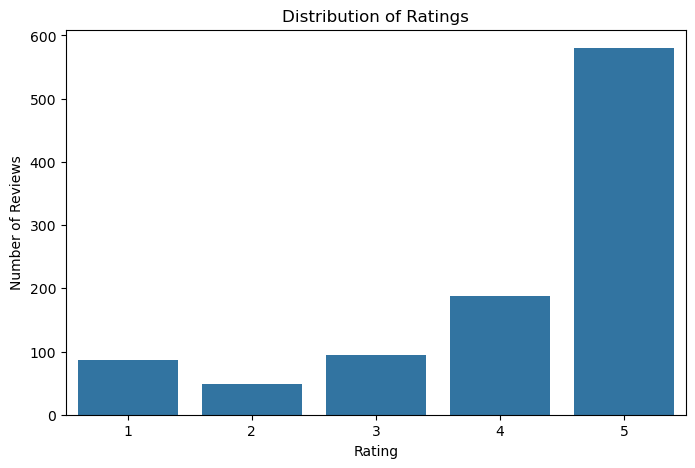

In [12]:
# Visulaize ratings
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='rating')

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

In [13]:
# TODO: Create preprocessing tools such as

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [14]:
# preprocessing function

def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    #Tokenize the text
    tokens = word_tokenize(text)
    
    # Keep alphabetic tokens only
    tokens = [word for word in tokens if word.isalpha()]
    
    #Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    #Lemmatize words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    #Return cleaned tokens
    return tokens

In [16]:
# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

df['processed_tokens'] = df['review_text'].apply(preprocess_text)

In [18]:
# TODO: Combine all tokens into one list so you can compute word frequencies.

all_tokens = [
    token
    for tokens in df['processed_tokens']
    for token in tokens
]

len(all_tokens)

72792

In [19]:
# TODO: Use Counter to identify the most common words

word_counts = Counter(all_tokens)

word_counts.most_common(20)

[('nook', 1516),
 ('book', 914),
 ('one', 569),
 ('kindle', 566),
 ('screen', 498),
 ('like', 460),
 ('read', 454),
 ('work', 447),
 ('get', 424),
 ('great', 422),
 ('use', 421),
 ('tablet', 421),
 ('tv', 416),
 ('device', 381),
 ('would', 378),
 ('good', 333),
 ('bn', 321),
 ('time', 319),
 ('also', 317),
 ('well', 306)]

In [ ]:

# TODO: Generate bigrams from the token list and identify the most common bigrams.

all_bigrams = []

for tokens in df['processed_tokens']:
    all_bigrams.extend(bigrams(tokens))


all_bigrams[:20]


[('film', 'definitely'),
 ('definitely', 'anyone'),
 ('anyone', 'especially'),
 ('especially', 'fond'),
 ('fond', 'independent'),
 ('independent', 'delightfully'),
 ('delightfully', 'manipulative'),
 ('manipulative', 'clever'),
 ('clever', 'boy'),
 ('boy', 'brain'),
 ('brain', 'child'),
 ('child', 'samuel'),
 ('samuel', 'clemens'),
 ('clemens', 'classicas'),
 ('classicas', 'one'),
 ('one', 'example'),
 ('example', 'book'),
 ('book', 'great'),
 ('great', 'fun'),
 ('fun', 'scene')]

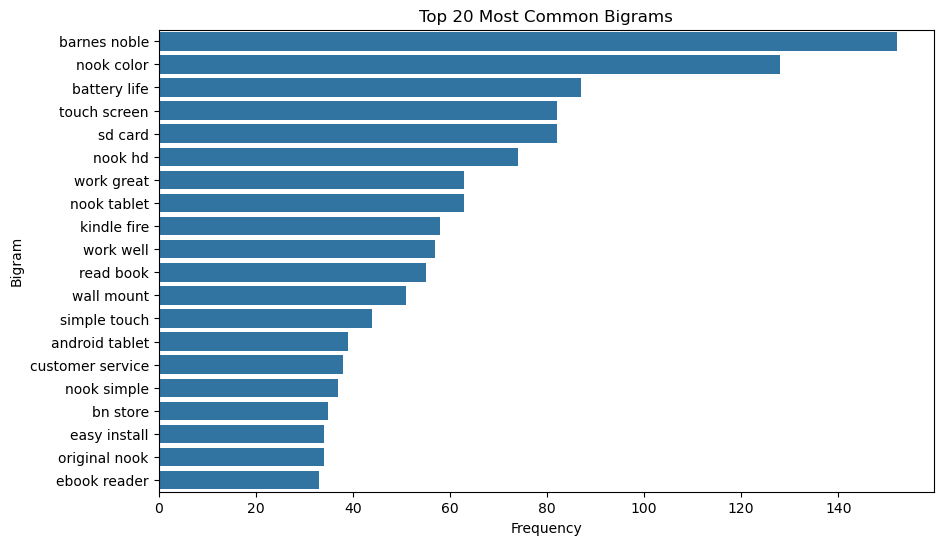

In [22]:
# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.


bigram_counts = Counter(all_bigrams)

bigram_counts.most_common(20)

common_bigrams = pd.DataFrame(
    [
        (' '.join(bigram), count)
        for bigram, count in bigram_counts.most_common(20)
    ],
    columns=['bigram', 'frequency']
)

common_bigrams

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_bigrams,
    x='frequency',
    y='bigram'
)

plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

plt.show()

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?

The most common bigrams reveal that customers frequently discuss specific products and features, particularly barnes and nook devices. Phrases such as "nook color", "nook HD", and "Kindle Fire" indicate that product models and competing devices are common topics. Also there are feature related phrases such as "battery life", "touch screen", and "SD card" suggest that customers are concerned with device performance and functionality. Positive phrases such as "work great", "work well", and "easy install" indicate generally positive experiences with product performance and usability. Overall, the bigram analysis suggests that product functionality, device features, and customer experience are major themes in the reviews.


## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [ ]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need.

# TODO: Load the same review dataset.
# df = ...

# TODO: Convert the timestamp column to datetime format.

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

# TODO: Plot monthly review volume over time.

# TODO: Plot average monthly rating over time.

# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [ ]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# TODO: Load the dataset.
# df = ...

# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

# vectorizer = ...
# X_tfidf = ...

# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.

# TODO: One-hot encode the target values if your neural network setup requires it.

# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# model = ...

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

# TODO: Train the model and store the training history.
# history = ...

# TODO: Evaluate the model on the test set.

# TODO: Generate predictions on the test set.

# TODO: Create a classification report and/or confusion matrix to assess performance.

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?
